In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(
    include=['object']
).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [6]:
X = df.drop("charges", axis=1)

y = df["charges"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
model = RandomForestRegressor(

    n_estimators=200,

    criterion="squared_error",

    max_depth=10,

    min_samples_split=5,

    min_samples_leaf=2,

    max_features="sqrt",

    bootstrap=True,

    random_state=42,

    n_jobs=-1
)

In [10]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [11]:
y_pred = model.predict(X_test)

In [12]:
mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)

print("MAE :", mae)

print("R2 Score :", r2)

MSE : 19787152.582027696
MAE : 2645.889701624231
R2 Score : 0.8725454798123345


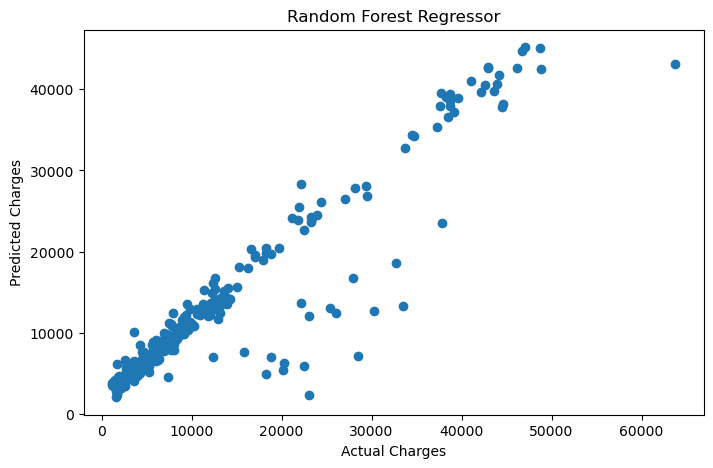

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Random Forest Regressor")

plt.show()

In [14]:
os.makedirs("../models", exist_ok=True)

In [15]:
pickle.dump(
    model,
    open(
        "../models/random_forest_model.pkl",
        "wb"
    )
)

pickle.dump(
    scaler,
    open(
        "../models/scaler.pkl",
        "wb"
    )
)